# Phase 1

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW # Changed import to torch.optim
from sklearn.model_selection import train_test_split
import numpy as np


MODEL_NAME = 'bert-base-uncased'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 2e-5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


df = pd.read_csv('Laptop_Train_v2.csv')

label_map = {'negative': 0, 'neutral': 1, 'positive': 2, 'conflict': 3}
df['label'] = df['polarity'].map(label_map)

df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

class ABSADataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['Sentence'].tolist()
        self.aspects = dataframe['Aspect Term'].tolist()
        self.labels = dataframe['label'].tolist()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        sentence = str(self.text[index])
        aspect = str(self.aspects[index])
        label = self.labels[index]

        encoding = self.tokenizer(
            sentence,
            aspect,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = ABSADataset(train_df, tokenizer, MAX_LEN)
val_dataset = ABSADataset(val_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=4)
model = model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)




Train size: 1886
Validation size: 236
Test size: 236


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


/tmp/ipython-input-1621459384.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='polarity', order=df['polarity'].value_counts().index, palette='viridis')


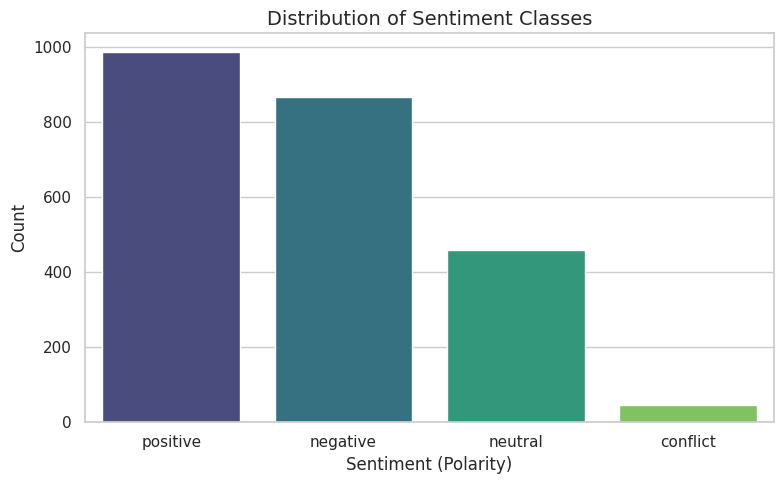

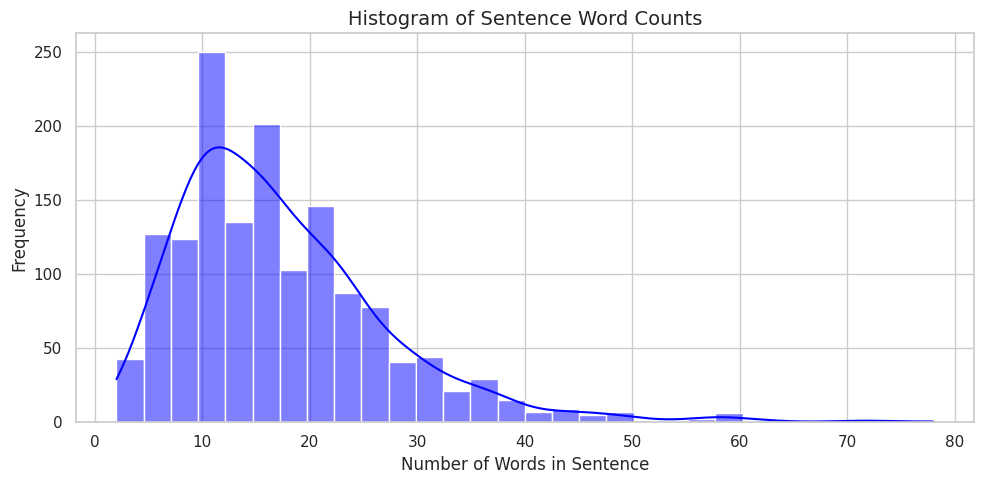

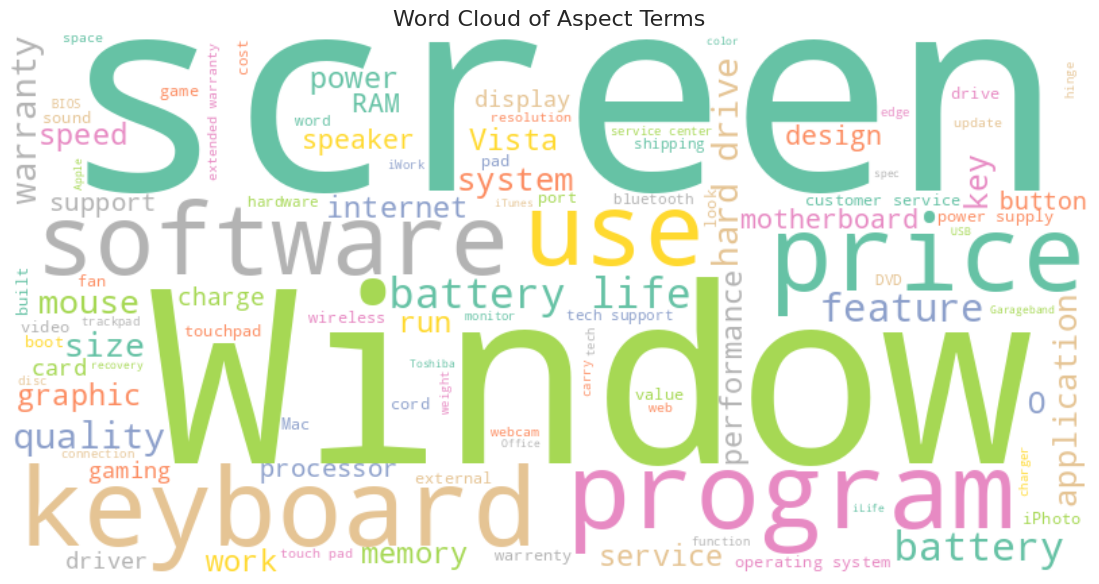

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud


df = pd.read_csv('Laptop_Train_v2.csv')

sns.set_theme(style="whitegrid")


plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='polarity', order=df['polarity'].value_counts().index, palette='viridis')
plt.title('Distribution of Sentiment Classes', fontsize=14)
plt.xlabel('Sentiment (Polarity)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()


unique_sentences = df[['id', 'Sentence']].drop_duplicates()

unique_sentences['word_count'] = unique_sentences['Sentence'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(data=unique_sentences, x='word_count', bins=30, kde=True, color='blue')
plt.title('Histogram of Sentence Word Counts', fontsize=14)
plt.xlabel('Number of Words in Sentence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('sentence_length_histogram.png')
plt.show()


text_aspects = " ".join(aspect for aspect in df['Aspect Term'].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Set2',
    max_words=100
).generate(text_aspects)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Aspect Terms', fontsize=16)
plt.tight_layout()
plt.savefig('aspects_wordcloud.png')
plt.show()

# Phase 2

In [ ]:
import copy

def train_epoch(model, data_loader, optimizer, device, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for batch in data_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)

history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

print("Starting Training...")
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}
best_val_loss = float('inf')
best_model_weights = None
for epoch in range(EPOCHS):
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, DEVICE, len(train_df))
    val_acc, val_loss = eval_model(model, val_loader, DEVICE, len(val_df))

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f'Train loss: {train_loss:.4f} | accuracy: {train_acc:.4f}')
    print(f'Val   loss: {val_loss:.4f} | accuracy: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f">>> Validation Loss improved to {best_val_loss:.4f}. Saving weights...")
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_bert_absa_model.pth')

    print('-' * 20)

print("Training completed. Loading best model weights for testing phase...")
model.load_state_dict(best_model_weights)

Starting Training...
Epoch 1/10
Train loss: 0.9077 | accuracy: 0.6379
Val   loss: 0.7294 | accuracy: 0.7415
>>> Validation Loss improved to 0.7294. Saving weights...
--------------------
Epoch 2/10
Train loss: 0.5737 | accuracy: 0.7990
Val   loss: 0.6149 | accuracy: 0.7839
>>> Validation Loss improved to 0.6149. Saving weights...
--------------------
Epoch 3/10
Train loss: 0.4281 | accuracy: 0.8574
Val   loss: 0.6114 | accuracy: 0.7924
>>> Validation Loss improved to 0.6114. Saving weights...
--------------------
Epoch 4/10
Train loss: 0.2935 | accuracy: 0.9072
Val   loss: 0.6812 | accuracy: 0.7712
--------------------
Epoch 5/10
Train loss: 0.2149 | accuracy: 0.9300
Val   loss: 0.7811 | accuracy: 0.7754
--------------------
Epoch 6/10
Train loss: 0.1536 | accuracy: 0.9475
Val   loss: 0.7198 | accuracy: 0.8008
--------------------
Epoch 7/10
Train loss: 0.1130 | accuracy: 0.9629
Val   loss: 0.7312 | accuracy: 0.8008
--------------------
Epoch 8/10
Train loss: 0.0752 | accuracy: 0.9788


<All keys matched successfully>

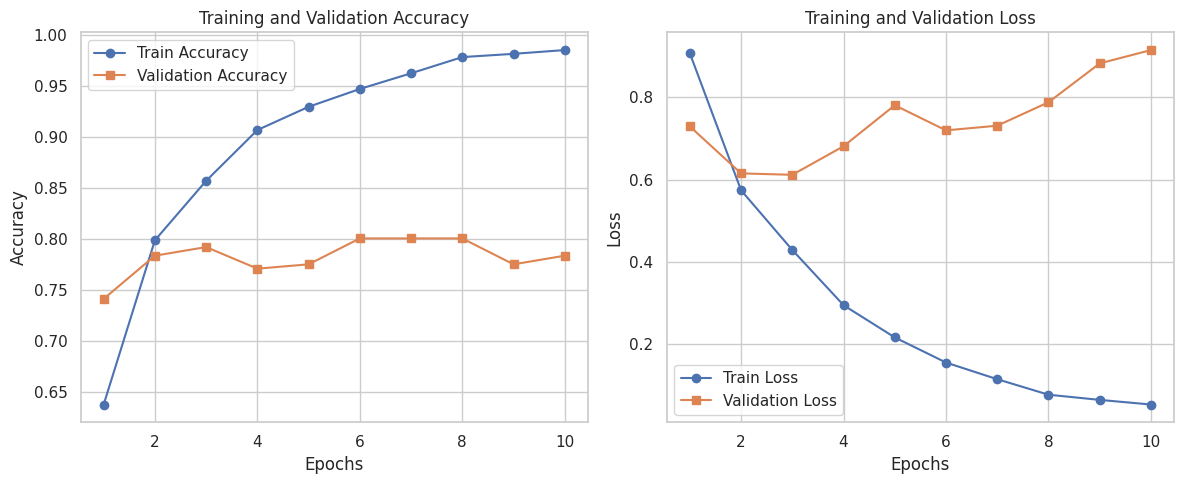

In [ ]:
import matplotlib.pyplot as plt

train_acc_list = [acc.item() if torch.is_tensor(acc) else acc for acc in history['train_acc']]
val_acc_list = [acc.item() if torch.is_tensor(acc) else acc for acc in history['val_acc']]

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc_list, label='Train Accuracy', marker='o')
plt.plot(epochs_range, val_acc_list, label='Validation Accuracy', marker='s')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
test_df.head()

,id,Sentence,Aspect Term,polarity,from,to,label
1647,2922,I have been very pleased with the performance ...,performance,positive,34,45,2
1389,2830,Now when I order I did not go full scale for t...,webcam,neutral,49,55,1
1964,2084,"If you want a little more custom ability, drop...",2GB stick of memory,positive,126,145,2
1014,1138,"Ever since I bought this laptop, so far I've e...",toshiba customer services,negative,160,185,0
2187,1182,"They don t translate from a Mac, even on Word,...",Word,negative,41,45,0


# Phase 3

Total test samples after merging: 236

[Phase 3 - A] Classification Report (including Macro-F1):
              precision    recall  f1-score   support

    negative       0.81      0.74      0.77        96
     neutral       0.50      0.47      0.48        47
    positive       0.73      0.87      0.80        87
    conflict       0.00      0.00      0.00         6

    accuracy                           0.72       236
   macro avg       0.51      0.52      0.51       236
weighted avg       0.70      0.72      0.70       236


[Phase 3 - B] Plotting Confusion Matrix...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


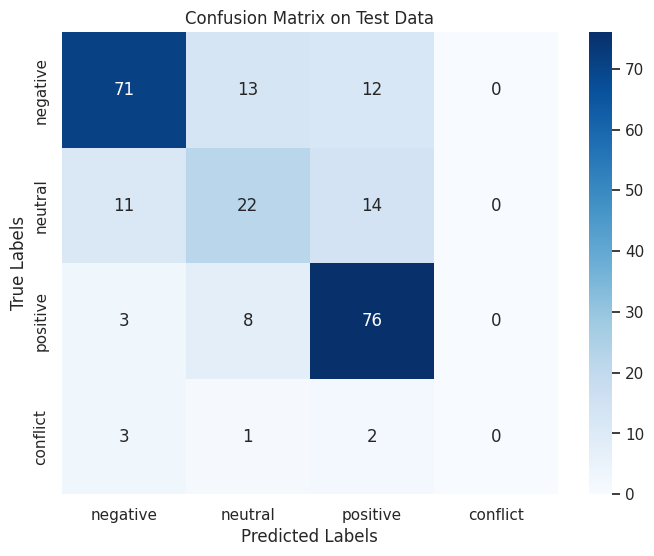


[Phase 3 - C] Extracting 5 Misclassified Examples for Error Analysis:

--- Error #1 ---
Sentence: If you want a little more custom ability, drop a few bucks and upgrade to one of the more robust versions of Win 7 and grab a 2GB stick of memory to spice it all up a bit more.
Aspect:   2GB stick of memory
True:     POSITIVE
Predicted:NEUTRAL

--- Error #2 ---
Sentence: also you may need to charge it once a day, if for medium use every thing fast and easy with mac  the size and look is the most feature that attracted me to it.
Aspect:   charge
True:     NEUTRAL
Predicted:POSITIVE

--- Error #3 ---
Sentence: The only thing I wish this had was the option to turn off the touchpad with a button like my big 16" laptop does.
Aspect:   touchpad
True:     NEGATIVE
Predicted:NEUTRAL

--- Error #4 ---
Sentence: I never had this kind of quality issue with Dell (not to say Dell is that great), not with a brand new laptop.
Aspect:   quality
True:     NEGATIVE
Predicted:POSITIVE

--- Error #5 ---
Sent

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print(f"Total test samples after merging: {len(test_df)}")

test_df['label'] = test_df['polarity'].map(label_map)
test_df = test_df.dropna(subset=['label'])
test_df['label'] = test_df['label'].astype(int)

test_dataset = ABSADataset(test_df, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=32)

model = model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

target_names = ['negative', 'neutral', 'positive', 'conflict']
print("\n[Phase 3 - A] Classification Report (including Macro-F1):")
print(classification_report(all_labels, all_preds, target_names=target_names))

print("\n[Phase 3 - B] Plotting Confusion Matrix...")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix on Test Data')
plt.show()

print("\n[Phase 3 - C] Extracting 5 Misclassified Examples for Error Analysis:")
test_df['predicted'] = all_preds
errors_df = test_df[test_df['label'] != test_df['predicted']]


reverse_label_map = {v: k for k, v in label_map.items()}

count = 0
for index, row in errors_df.head(5).iterrows():
    count += 1
    true_label_text = reverse_label_map[row['label']]
    pred_label_text = reverse_label_map[row['predicted']]

    print(f"\n--- Error #{count} ---")
    print(f"Sentence: {row['Sentence']}")
    print(f"Aspect:   {row['Aspect Term']}")
    print(f"True:     {true_label_text.upper()}")
    print(f"Predicted:{pred_label_text.upper()}")

total_errors = len(errors_df)
total_samples = len(test_df)
print(f"❌ Total misclassified examples: {total_errors} out of {total_samples}")
print(f"✅ Accuracy based on errors: {((total_samples - total_errors) / total_samples) * 100:.2f}%\n")

# Phase 4

In [ ]:
import pandas as pd
import torch

# 1. Define the 20 challenging sentences and their expected labels
test_cases = [
    ["If the battery weren’t bad, I wouldn’t need to charge it every two hours.", "battery", "negative"],
    ["The GUI isn’t terrible, but honestly it doesn’t feel good either.", "GUI", "conflict"],
    ["It’s not that the fan makes no noise — it’s actually very loud.", "fan", "negative"],
    ["If the keyboard weren’t so slippery, typing would be okay.", "keyboard", "negative"],
    ["The system doesn’t crash… except exactly when you need it most.", "system", "negative"],
    ["The screen is neither bright nor dark — just average.", "screen", "neutral"],
    ["If the software didn’t crash sometimes, performance would be fine.", "software", "conflict"],
    ["I can’t say the battery life isn’t good… but it’s not really good.", "battery life", "conflict"],
    ["The charger isn’t completely useless, but it barely works.", "charger", "negative"],
    ["If you don’t expect speed, the processor isn’t disappointing.", "processor", "neutral"],
    ["The warranty isn’t not helpful, but support takes forever.", "warranty", "conflict"],
    ["I wouldn’t say the speakers sound bad, just not impressive.", "speakers", "neutral"],
    ["The touchpad is fine if you don’t mind random glitches.", "touchpad", "negative"],
    ["The software isn’t buggy — it just crashes occasionally.", "software", "negative"],
    ["The battery doesn’t fail often, but when it does, it’s awful.", "battery", "conflict"],
    ["The screen isn’t unusable, just far from sharp.", "screen", "negative"],
    ["If the battery were any better, I’d forget where my charger is.", "battery", "positive"],
    ["The screen isn’t just good — it’s extremely sharp.", "screen", "positive"],
    ["I can’t say the keyboard isn’t comfortable — it really is.", "keyboard", "positive"],
    ["Not only is the battery life good, it’s surprisingly great.", "battery life", "positive"]
]

# 2. Define the Inference Function
def predict_aspect_sentiment(sentence, aspect, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        sentence,
        aspect,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    # Reverse label map: {0: 'negative', 1: 'neutral', 2: 'positive'}
    inv_label_map = {0: 'negative', 1: 'neutral', 2: 'positive', 3: 'conflict'}
    return inv_label_map[prediction]

# 3. Run evaluation and display results
results = []
correct_predictions = 0

print(f"{'#':<3} | {'Aspect':<12} | {'Expected':<10} | {'Predicted':<10} | {'Result'}")
print("-" * 65)

for i, (sentence, aspect, expected) in enumerate(test_cases):
    predicted = predict_aspect_sentiment(sentence, aspect, model, tokenizer, DEVICE)
    is_correct = "✅" if predicted == expected else "❌"
    if predicted == expected:
        correct_predictions += 1

    results.append({
        "Sentence": sentence,
        "Aspect": aspect,
        "Expected": expected,
        "Predicted": predicted,
        "Correct": predicted == expected
    })

    print(f"{i+1:<3} | {aspect:<12} | {expected:<10} | {predicted:<10} | {is_correct}")

print("-" * 65)
print(f"Final Score: {correct_predictions}/20 ({(correct_predictions/20)*100}%)")

#   | Aspect       | Expected   | Predicted  | Result
-----------------------------------------------------------------
1   | battery      | negative   | positive   | ❌
2   | GUI          | conflict   | negative   | ❌
3   | fan          | negative   | positive   | ❌
4   | keyboard     | negative   | negative   | ✅
5   | system       | negative   | positive   | ❌
6   | screen       | neutral    | positive   | ❌
7   | software     | conflict   | negative   | ❌
8   | battery life | conflict   | negative   | ❌
9   | charger      | negative   | negative   | ✅
10  | processor    | neutral    | positive   | ❌
11  | warranty     | conflict   | negative   | ❌
12  | speakers     | neutral    | negative   | ❌
13  | touchpad     | negative   | positive   | ❌
14  | software     | negative   | negative   | ✅
15  | battery      | conflict   | negative   | ❌
16  | screen       | negative   | negative   | ✅
17  | battery      | positive   | negative   | ❌
18  | screen       | positive   | positive   | 

In [3]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# --- Setup Device and Model ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = 'bert-base-uncased'
MODEL_PATH = 'best_bert_absa_model.pth'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Initialize the architecture (ensure num_labels matches your trained model)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

# Load the saved weights
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print("Model weights loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")

model.to(DEVICE)

# 1. Define the modified sentence
test_cases = [
    ["The software isn’t buggy — but you can't expect it to work well all the time.", "software", "negative"]
]

# 2. Define the Inference Function
def predict_aspect_sentiment(sentence, aspect, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        sentence,
        aspect,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=1).item()

    # Label map consistent with your 3-class fix
    inv_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
    return inv_label_map[prediction]

# 3. Run evaluation
results = []
correct_predictions = 0

print(f"{'#':<3} | {'Aspect':<12} | {'Expected':<10} | {'Predicted':<10} | {'Result'}")
print("-" * 75)

for i, (sentence, aspect, expected) in enumerate(test_cases):
    predicted = predict_aspect_sentiment(sentence, aspect, model, tokenizer, DEVICE)
    is_correct = "✅" if predicted == expected else "❌"
    if predicted == expected:
        correct_predictions += 1

    print(f"{i+1:<3} | {aspect:<12} | {expected:<10} | {predicted:<10} | {is_correct}")

print("-" * 75)
print(f"Final Score: {correct_predictions}/1 ({(correct_predictions/1)*100}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Error loading model: [Errno 2] No such file or directory: 'best_bert_absa_model.pth'
#   | Aspect       | Expected   | Predicted  | Result
---------------------------------------------------------------------------
1   | software     | negative   | neutral    | ❌
---------------------------------------------------------------------------
Final Score: 0/20 (0.0%)
